In [3]:
# load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

In [5]:
df = pd.read_csv('../data/raw/student_lifestyle_dataset.csv')
df = df.drop(columns=['Student_ID'])

print(f"Shape : {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape : 2000 rows, 7 columns


,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,8.1,0.6,6.5,2.2,6.6,3.51,High


In [6]:
print(f"Data Types: \n{df.dtypes}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Data Types: 
Study_Hours_Per_Day                float64
Extracurricular_Hours_Per_Day      float64
Sleep_Hours_Per_Day                float64
Social_Hours_Per_Day               float64
Physical_Activity_Hours_Per_Day    float64
GPA                                float64
Stress_Level                        object
dtype: object

Missing Values: 0

Duplicate Rows: 0


In [7]:
df.describe().round(3)

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,7.476,1.990,7.501,2.705,4.328,3.116
std,1.424,1.156,1.461,1.689,2.514,0.299
min,5.000,0.000,5.000,0.000,0.000,2.240
25%,6.300,1.000,6.200,1.200,2.400,2.900
50%,7.400,2.000,7.500,2.600,4.100,3.110
75%,8.700,3.000,8.800,4.100,6.100,3.330
max,10.000,4.000,10.000,6.000,13.000,4.000


  Low       :  297  (14.8%)
  Moderate  :  674  (33.7%)
  High      : 1029  (51.4%)


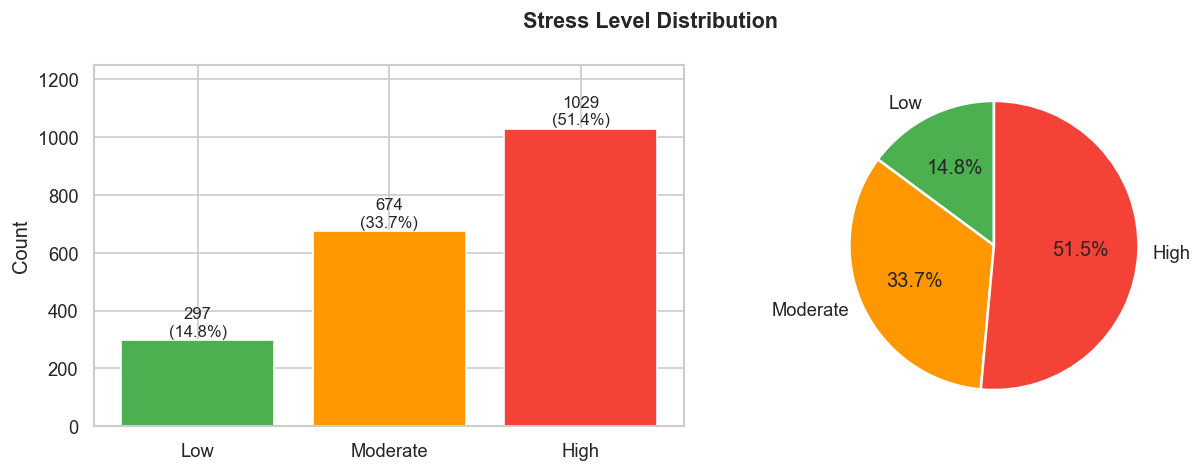

In [8]:
ORDER   = ['Low', 'Moderate', 'High']
PALETTE = {'Low': '#4CAF50', 'Moderate': '#FF9800', 'High': '#F44336'}

counts = df['Stress_Level'].value_counts().reindex(ORDER)
pcts   = df['Stress_Level'].value_counts(normalize=True).reindex(ORDER) * 100

for lvl, cnt, pct in zip(ORDER, counts, pcts):
    print(f"  {lvl:<10}: {cnt:>4}  ({pct:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Stress Level Distribution", fontsize=13, fontweight='bold')

axes[0].bar(ORDER, counts, color=[PALETTE[l] for l in ORDER], edgecolor='white')
for i, (cnt, pct) in enumerate(zip(counts, pcts)):
    axes[0].text(i, cnt + 15, f"{cnt}\n({pct:.1f}%)", ha='center', fontsize=10)
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 1250)

axes[1].pie(counts, labels=ORDER, autopct='%1.1f%%',
            colors=[PALETTE[l] for l in ORDER],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))

plt.tight_layout()
plt.show()

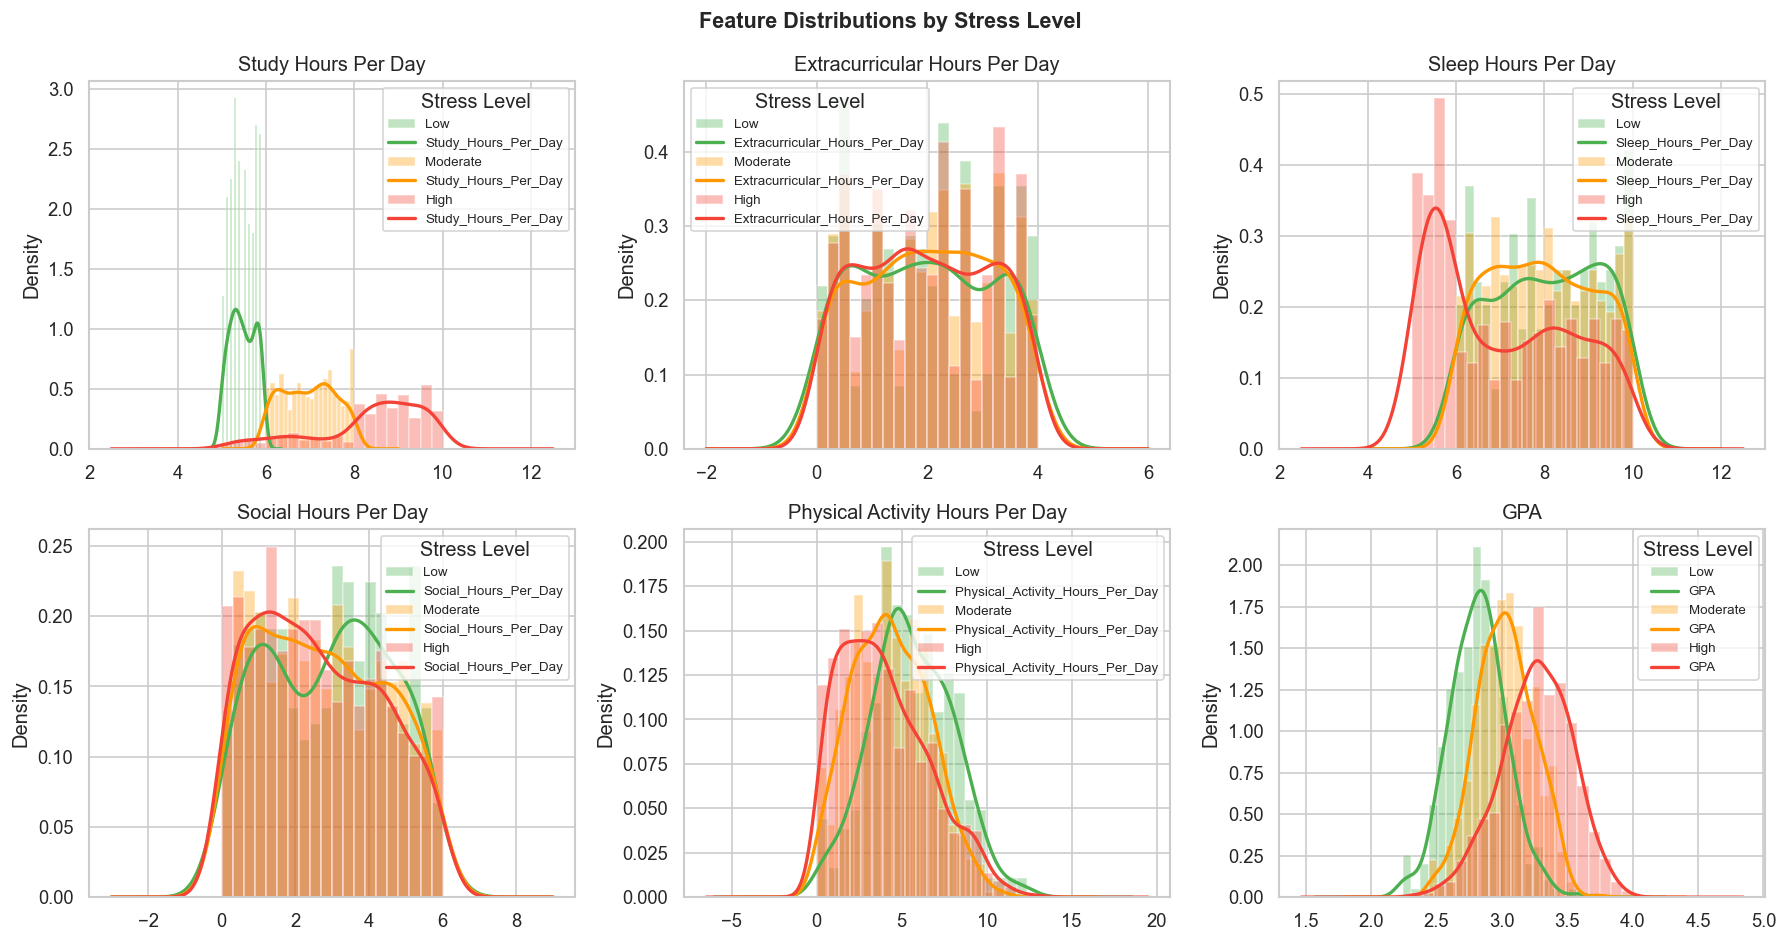

In [9]:
FEATURES = ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day',
            'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day',
            'Physical_Activity_Hours_Per_Day', 'GPA']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Feature Distributions by Stress Level", fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    for lvl in ORDER:
        subset = df[df['Stress_Level'] == lvl][feat]
        axes[i].hist(subset, bins=20, alpha=0.35, color=PALETTE[lvl], label=lvl, density=True)
        subset.plot.kde(ax=axes[i], color=PALETTE[lvl], linewidth=2)
    axes[i].set_title(feat.replace('_', ' '))
    axes[i].set_ylabel("Density")
    axes[i].legend(title="Stress Level", fontsize=8)

plt.tight_layout()
plt.show()

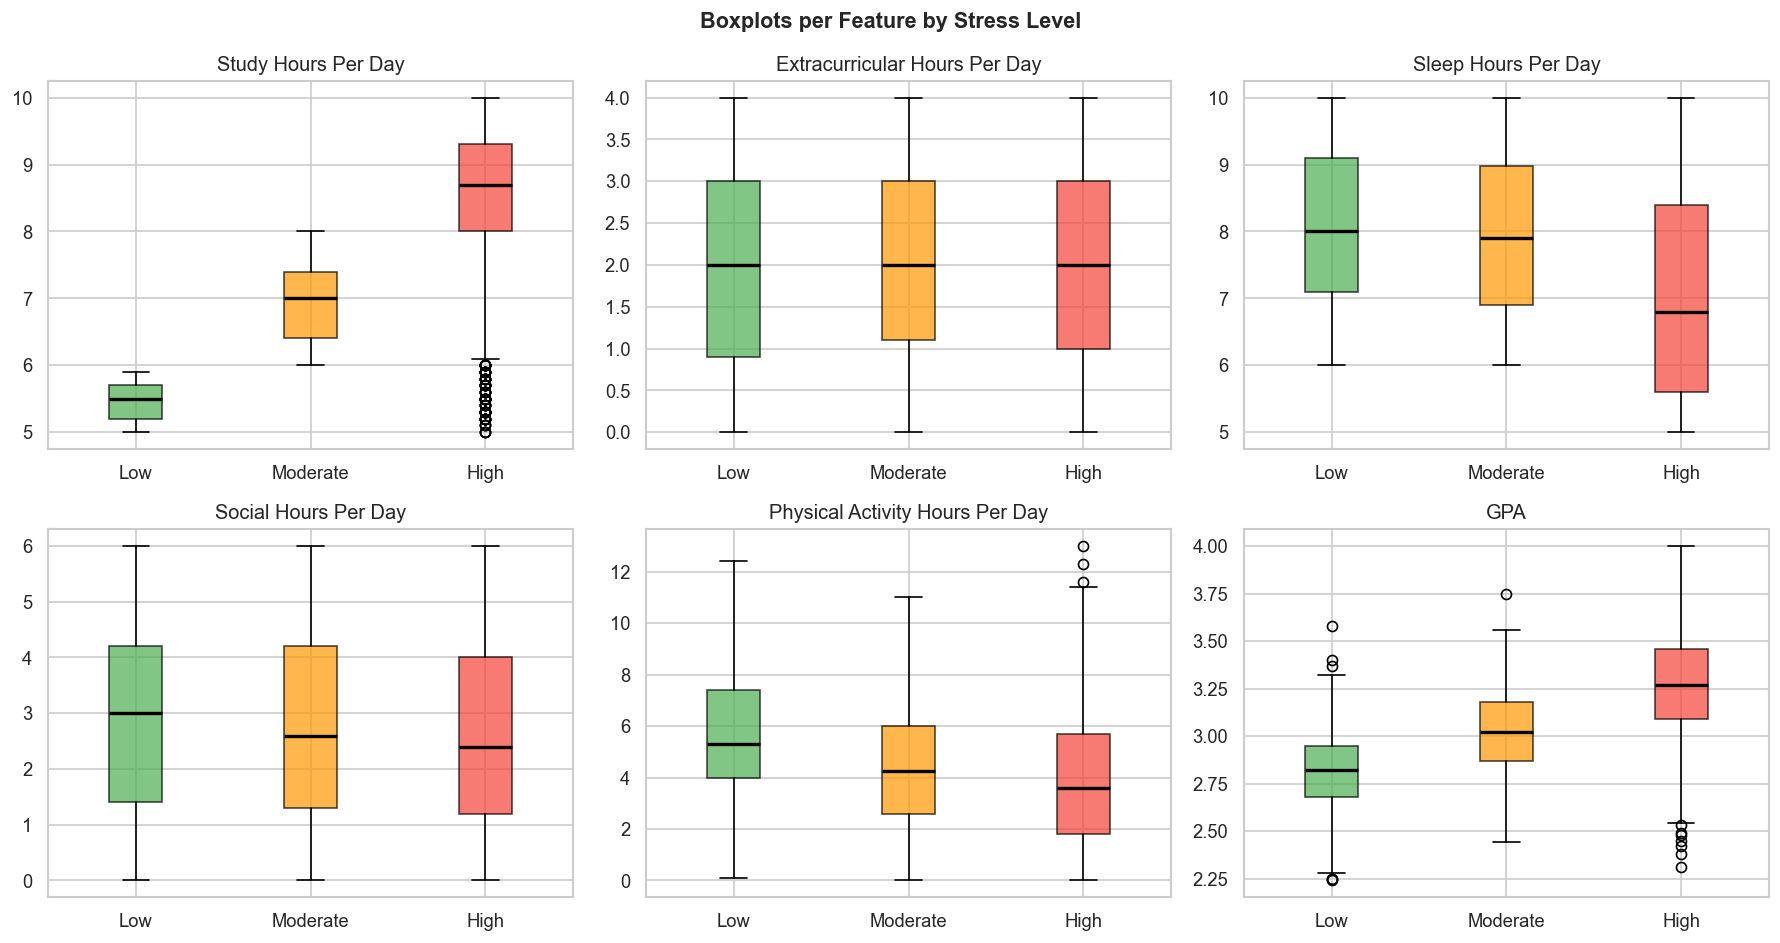

Outlier Count (IQR method):
  Study_Hours_Per_Day                       : 0 outliers
  Extracurricular_Hours_Per_Day             : 0 outliers
  Sleep_Hours_Per_Day                       : 0 outliers
  Social_Hours_Per_Day                      : 0 outliers
  Physical_Activity_Hours_Per_Day           : 5 outliers
  GPA                                       : 4 outliers


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Boxplots per Feature by Stress Level", fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    data_by_class = [df[df['Stress_Level'] == lvl][feat].values for lvl in ORDER]
    bp = axes[i].boxplot(data_by_class, labels=ORDER, patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    for patch, lvl in zip(bp['boxes'], ORDER):
        patch.set_facecolor(PALETTE[lvl])
        patch.set_alpha(0.7)
    axes[i].set_title(feat.replace('_', ' '))

plt.tight_layout()
plt.show()

print("Outlier Count (IQR method):")
for feat in FEATURES:
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    print(f"  {feat:<42}: {n_out} outliers")

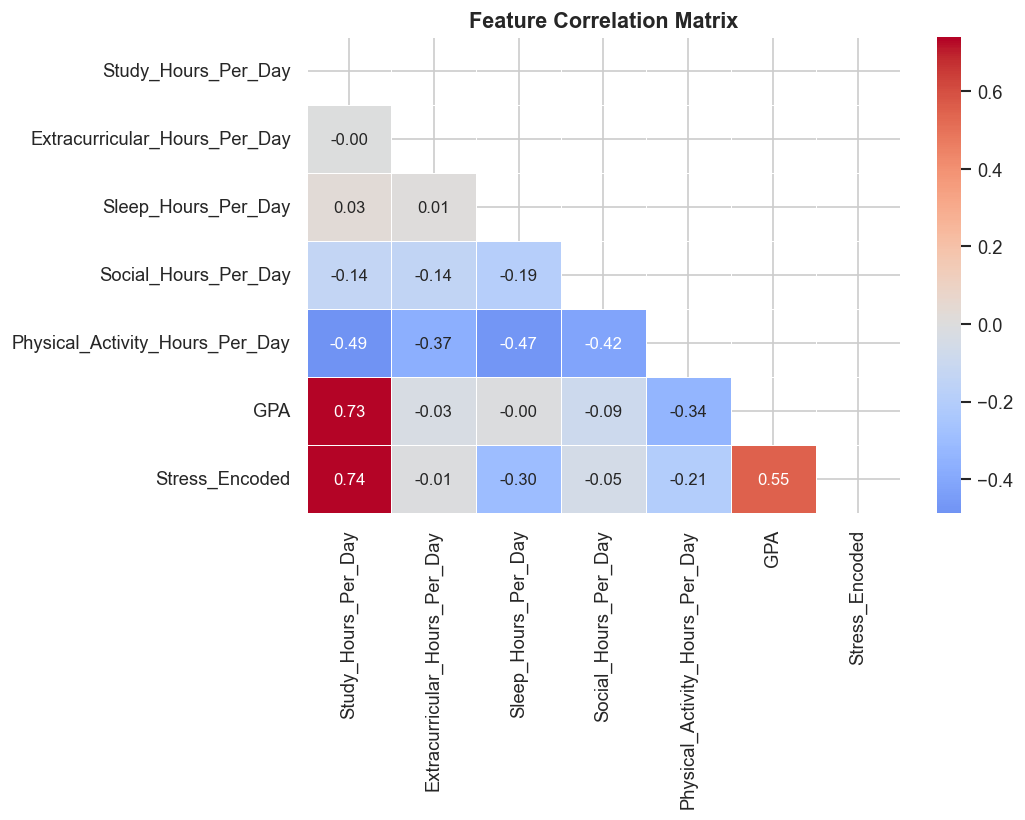

In [11]:
df_encoded = df.copy()
df_encoded['Stress_Encoded'] = df['Stress_Level'].map({'Low': 0, 'Moderate': 1, 'High': 2})

fig, ax = plt.subplots(figsize=(9, 7))
corr = df_encoded[FEATURES + ['Stress_Encoded']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

              Study_Hours_Per_Day  Extracurricular_Hours_Per_Day  Sleep_Hours_Per_Day  Social_Hours_Per_Day  Physical_Activity_Hours_Per_Day    GPA
Stress_Level                                                                                                                                       
Low                         5.474                          1.989                8.064                 2.891                            5.582  2.817
Moderate                    6.970                          2.006                7.948                 2.740                            4.337  3.025
High                        8.385                          1.980                7.046                 2.628                            3.961  3.262


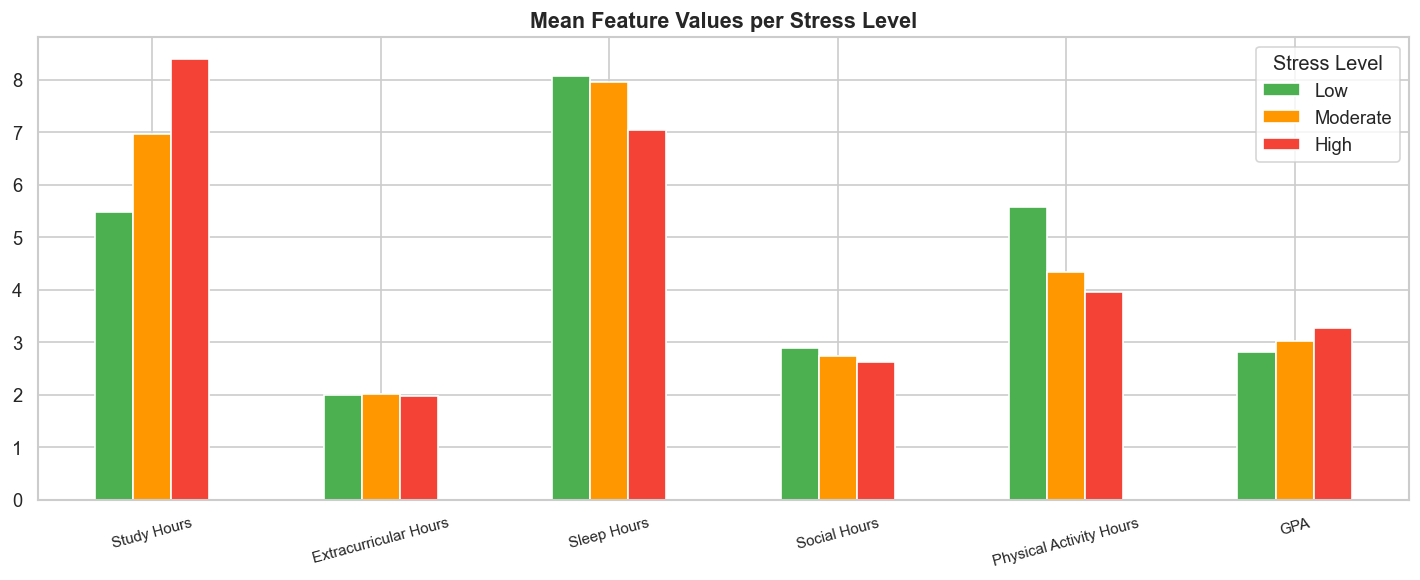

In [12]:
mean_table = df.groupby('Stress_Level')[FEATURES].mean().reindex(ORDER).round(3)
print(mean_table.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
mean_table.T.plot(kind='bar', ax=ax, color=[PALETTE[l] for l in ORDER], edgecolor='white')
ax.set_title("Mean Feature Values per Stress Level", fontsize=13, fontweight='bold')
ax.set_xticklabels([f.replace('_Per_Day','').replace('_',' ') for f in FEATURES], rotation=15, fontsize=9)
ax.legend(title="Stress Level")
plt.tight_layout()
plt.show()

EDA SUMMARY - KEY FINDINGS

From Dataset:
- Dataset : 2000 rows, 6 features, 1 target
- Quality : No missing values, no duplicates
- Outliers : Minimal
- Features : All 6 features are present

Class Imbalance
- High : 1029 (51.5%)
- Moderate : 674 (33.7%)
- Low : 297 (14.9%)

Key Patterns
- The amount of study hours and stress level is linear
- Lower sleep hours means higher stress level
- Lower physical activity means higher stress level
